In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuramos para que los gráficos se vean bien
%matplotlib inline
sns.set_theme(style="whitegrid")

# Definimos la ruta a los datos (ajustala según tu carpeta actual)
# Si estás en 'notebooks/', tenés que subir un nivel para entrar a 'data/raw/'
data_path = "../data/raw/"

print("Librerías cargadas y listas.")

Librerías cargadas y listas.


In [3]:
# Cargamos artículos y clientes completos
articles = pd.read_csv(os.path.join(data_path, "articles.csv"))
customers = pd.read_csv(os.path.join(data_path, "customers.csv"))

print(f"Artículos cargados: {articles.shape}")
print(f"Clientes cargados: {customers.shape}")

Artículos cargados: (105542, 25)
Clientes cargados: (1371980, 7)


In [4]:
# 1. Usamos dtypes más livianos para no saturar la RAM
t_dtypes = {
    'article_id': 'int32',
    'sales_channel_id': 'int8',
    'price': 'float32'
}

print("Cargando el archivo completo de transacciones para el muestreo...")

# Leemos el archivo gigante optimizando la memoria
df_all = pd.read_csv(
    os.path.join(data_path, "transactions_train.csv"),
    dtype=t_dtypes,
    usecols=['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']
)

# 2. Convertimos a fecha y extraemos el mes y año
df_all['t_dat'] = pd.to_datetime(df_all['t_dat'])
df_all['year_month'] = df_all['t_dat'].dt.to_period('M')

# 3. Muestreo Estratificado (10,000 transacciones por cada mes)
samples_per_month = 10000
df_stratified = df_all.groupby('year_month').apply(
    lambda x: x.sample(n=min(len(x), samples_per_month), random_state=42)
).reset_index(drop=True)

# 4. Limpiamos la RAM borrando el dataframe gigante original
del df_all

print("\nDistribución de transacciones por mes en la muestra técnica:")
print(df_stratified['year_month'].value_counts().sort_index())
print("\n¡Muestreo técnico completado con éxito!")

Cargando el archivo completo de transacciones para el muestreo... ⏳


C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_4052\2571832728.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_stratified = df_all.groupby('year_month').apply(



Distribución de transacciones por mes en la muestra técnica:
year_month
2018-09    10000
2018-10    10000
2018-11    10000
2018-12    10000
2019-01    10000
2019-02    10000
2019-03    10000
2019-04    10000
2019-05    10000
2019-06    10000
2019-07    10000
2019-08    10000
2019-09    10000
2019-10    10000
2019-11    10000
2019-12    10000
2020-01    10000
2020-02    10000
2020-03    10000
2020-04    10000
2020-05    10000
2020-06    10000
2020-07    10000
2020-08    10000
2020-09    10000
Freq: M, Name: count, dtype: int64

¡Muestreo técnico completado con éxito! ✅


In [7]:
print("="*50)
print("PERFIL DE LA TABLA: CUSTOMERS")
print("="*50)

# Información de tipos de datos y nulos
customers.info()

print("\n--- Primeros 5 registros ---")
# Usamos display() si estás en Jupyter para que salga como tablita linda, 
# o display(customers.head())
display(customers.head())

PERFIL DE LA TABLA: CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB

--- Primeros 5 registros ---


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [8]:
print("="*50)
print("PERFIL DE LA TABLA: ARTICLES")
print("="*50)

articles.info()

print("\n--- Primeros 3 registros ---")
display(articles.head(3))

PERFIL DE LA TABLA: ARTICLES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id   

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


In [9]:
print("="*50)
print("PERFIL DE LA TABLA: TRANSACTIONS (Muestra)")
print("="*50)

df_stratified.info()

print("\n--- Primeros 5 registros ---")
display(df_stratified.head())

print("\n--- Resumen Estadístico Rápido ---")
# .describe() nos da media, desvío, min, max de las columnas numéricas
display(df_stratified.describe())

PERFIL DE LA TABLA: TRANSACTIONS (Muestra)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   t_dat             250000 non-null  datetime64[ns]
 1   customer_id       250000 non-null  object        
 2   article_id        250000 non-null  int32         
 3   price             250000 non-null  float32       
 4   sales_channel_id  250000 non-null  int8          
 5   year_month        250000 non-null  period[M]     
dtypes: datetime64[ns](1), float32(1), int32(1), int8(1), object(1), period[M](1)
memory usage: 7.9+ MB

--- Primeros 5 registros ---


,t_dat,customer_id,article_id,price,sales_channel_id,year_month
0,2018-09-21,3480f2d31e5888eb27eb3dafb5deac591004798634d78d...,514577014,0.016932,1,2018-09
1,2018-09-25,e02d21aea5c82d7f712646052f862c7c11bc3bd0e43047...,237222001,0.016932,2,2018-09
2,2018-09-26,a31b67dcef05b50f974eb4e7b3cecc11c9a2b3b62a30d1...,587026012,0.050831,1,2018-09
3,2018-09-23,515056fc0d673b7d9c3d8c3ec5a9e1d4293e9f787baefa...,579541001,0.016932,2,2018-09
4,2018-09-27,52e04afb5a402c2e6046ab51393a9b83459099373227f7...,656719005,0.050831,2,2018-09



--- Resumen Estadístico Rápido ---


,t_dat,article_id,price,sales_channel_id
count,250000,2.500000e+05,250000.000000,250000.000000
mean,2019-09-16 04:33:50.515200,6.959762e+08,0.028154,1.705032
min,2018-09-20 00:00:00,1.087750e+08,0.000169,1.000000
25%,2019-03-09 00:00:00,6.306385e+08,0.016085,1.000000
50%,2019-09-18 00:00:00,7.133360e+08,0.025407,2.000000
75%,2020-03-24 00:00:00,7.890510e+08,0.033881,2.000000
max,2020-09-22 00:00:00,9.537630e+08,0.506780,2.000000
std,NaN,1.348845e+08,0.019607,0.456029


In [5]:
print("--- 1. ANÁLISIS DE VALORES NULOS ---")
print("Columnas con nulos en Clientes:")
nulos_clientes = customers.isnull().sum()
print(nulos_clientes[nulos_clientes > 0])

print("\nColumnas con nulos en Artículos:")
nulos_articulos = articles.isnull().sum()
print(nulos_articulos[nulos_articulos > 0])

print("\nColumnas con nulos en Transacciones (Muestra):")
nulos_transacciones = df_stratified.isnull().sum()
# Si está vacío, imprimimos un mensaje amigable
if nulos_transacciones[nulos_transacciones > 0].empty:
    print("¡No hay nulos en las transacciones!")
else:
    print(nulos_transacciones[nulos_transacciones > 0])

print("\n--- 2. DUPLICADOS TÉCNICOS (Claves Primarias) ---")
# Una clave primaria (como el ID del cliente o del artículo) NUNCA debe repetirse
print(f"IDs de clientes repetidos: {customers.duplicated(subset=['customer_id']).sum()}")
print(f"IDs de artículos repetidos: {articles.duplicated(subset=['article_id']).sum()}")

# En transacciones, un duplicado exacto significa que el mismo cliente compró 
# el mismo artículo, al mismo precio, en el mismo canal y en el mismo instante.
print(f"Transacciones 100% idénticas (posible error de sistema): {df_stratified.duplicated().sum()}")

--- 1. ANÁLISIS DE VALORES NULOS ---
Columnas con nulos en Clientes:
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
dtype: int64

Columnas con nulos en Artículos:
detail_desc    416
dtype: int64

Columnas con nulos en Transacciones (Muestra):
¡No hay nulos en las transacciones!

--- 2. DUPLICADOS TÉCNICOS (Claves Primarias) ---
IDs de clientes repetidos: 0
IDs de artículos repetidos: 0
Transacciones 100% idénticas (posible error de sistema): 299


### Conclusiones del Análisis Estructural y Valores Nulos

1. **Robustez de Claves Primarias:** No existen duplicados en las claves primarias (`customer_id` y `article_id`). Esto confirma que los catálogos maestros no tienen redundancias técnicas.
2. **Nulos de Negocio vs. Nulos de Sistema:** - Las columnas `FN` (Fashion News) y `Active` presentan más de 895,000 nulos. Desde una perspectiva de sistemas, esto no es un error de carga, sino una "ausencia de acción" (usuarios no suscritos). Se imputarán como `0`.
   - La columna `age` tiene solo 15,861 nulos (aprox. 1.1% del total). Se aplicará una imputación por la mediana para no perder esos registros.
   - En `articles`, la falta de `detail_desc` en 416 registros se tratará asignando una categoría de "Sin descripción".
3. **Duplicados en Transacciones (299 registros):** Se detectaron 299 transacciones 100% idénticas. Dado que el dataset no posee una columna `quantity` (cantidad), concluimos que estructuralmente el sistema registra la compra de *N* artículos idénticos en el mismo carrito como *N* filas separadas. No se consideran errores de duplicación de base de datos.

In [6]:
print("--- 3. INTEGRIDAD REFERENCIAL ---")
# ¿Hay artículos vendidos que no existen en el catálogo?
articulos_vendidos = df_stratified['article_id'].unique()
articulos_catalogo = articles['article_id'].unique()
articulos_huerfanos = set(articulos_vendidos) - set(articulos_catalogo)
print(f"Artículos vendidos que NO existen en articles.csv: {len(articulos_huerfanos)}")

# ¿Hay clientes comprando que no están registrados?
clientes_comprando = df_stratified['customer_id'].unique()
clientes_registrados = customers['customer_id'].unique()
clientes_huerfanos = set(clientes_comprando) - set(clientes_registrados)
print(f"Clientes con compras que NO existen en customers.csv: {len(clientes_huerfanos)}")

print("\n--- 4. ANOMALÍAS EN RANGOS (Valores Imposibles) ---")
# Precios iguales o menores a 0
precios_invalidos = df_stratified[df_stratified['price'] <= 0].shape[0]
print(f"Transacciones con precio inválido (<= 0): {precios_invalidos}")

# Revisión de edades
print("\nEstadísticas de Edad (Buscando mínimos y máximos irreales):")
print(customers['age'].describe()[['min', 'max', 'mean']])

--- 3. INTEGRIDAD REFERENCIAL ---
Artículos vendidos que NO existen en articles.csv: 0
Clientes con compras que NO existen en customers.csv: 0

--- 4. ANOMALÍAS EN RANGOS (Valores Imposibles) ---
Transacciones con precio inválido (<= 0): 0

Estadísticas de Edad (Buscando mínimos y máximos irreales):
min     16.000000
max     99.000000
mean    36.386965
Name: age, dtype: float64


### Conclusiones de Integridad Referencial y Rangos

1. **Integridad Referencial Perfecta (0 Huérfanos):** El cruce entre la tabla de hechos (`transactions_train.csv`) y las tablas dimensionales (`articles.csv` y `customers.csv`) devolvió **0 anomalías**. Todo artículo vendido existe en el catálogo y todo cliente que compró está registrado. La base de datos es consistente a nivel relacional.
2. **Validación de Reglas de Negocio (Rangos):**
   - **Precios:** No se detectaron precios negativos ni iguales a cero (0 transacciones inválidas). Los datos están normalizados correctamente.
   - **Edades:** El rango de edad va de 16 (mínimo legal probable para compras) a 99 años, con una media de 36.3 años. No existen "edades basura" (ej. negativos o > 150 años) generadas por errores de tipeo del usuario en el front-end.

In [5]:
# Listamos las columnas de cada dataframe para entender las relaciones
print("--- Columnas de ARTÍCULOS ---")
print(articles.columns.tolist())

print("\n--- Columnas de CLIENTES ---")
print(customers.columns.tolist())

print("\n--- Columnas de TRANSACCIONES ---")
print(transactions_sample.columns.tolist())

--- Columnas de ARTÍCULOS ---
['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']

--- Columnas de CLIENTES ---
['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

--- Columnas de TRANSACCIONES ---
['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']


In [6]:
# Revisamos valores nulos en porcentajes
print("Porcentaje de nulos en Clientes:")
print((customers.isnull().sum() / len(customers) * 100).sort_values(ascending=False))

# Revisamos si hay duplicados en artículos (no debería haber IDs repetidos)
duplicados_art = articles.duplicated(subset=['article_id']).sum()
print(f"\nArtículos con ID duplicado: {duplicados_art}")

Porcentaje de nulos en Clientes:
Active                    66.150819
FN                        65.237831
fashion_news_frequency     1.167000
age                        1.156066
club_member_status         0.441843
customer_id                0.000000
postal_code                0.000000
dtype: float64

Artículos con ID duplicado: 0


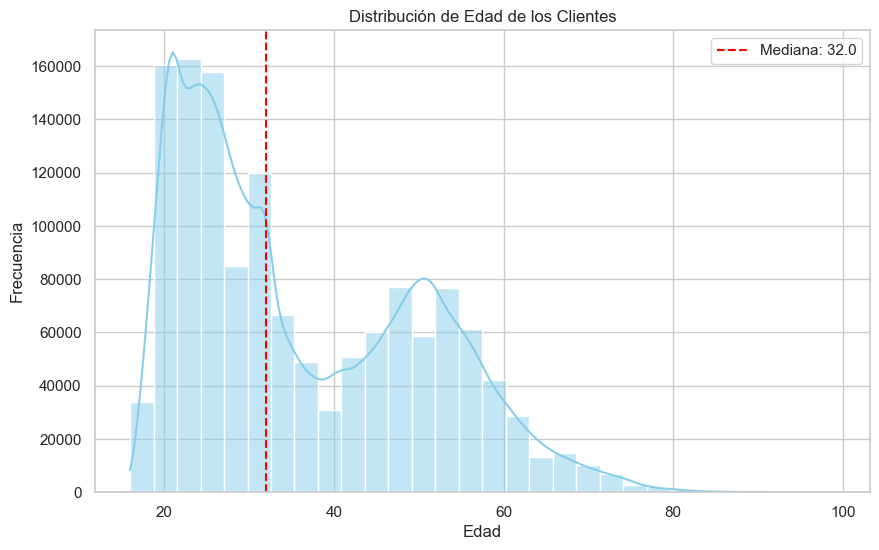

Nulos en 'age' después de la limpieza: 0


In [7]:
# 1. Tratamiento de nulos en Customers
customers['Active'] = customers['Active'].fillna(0)
customers['FN'] = customers['FN'].fillna(0)

# Rellenamos la edad con la mediana (es más robusta que el promedio ante outliers)
age_median = customers['age'].median()
customers['age'] = customers['age'].fillna(age_median)

# 2. Visualización de la distribución de edad
plt.figure(figsize=(10, 6))
sns.histplot(customers['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Edad de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.axvline(age_median, color='red', linestyle='--', label=f'Mediana: {age_median}')
plt.legend()
plt.show()

print(f"Nulos en 'age' después de la limpieza: {customers['age'].isnull().sum()}")

C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\1454548085.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=articles, y='index_group_name', order=articles['index_group_name'].value_counts().index, palette='viridis')


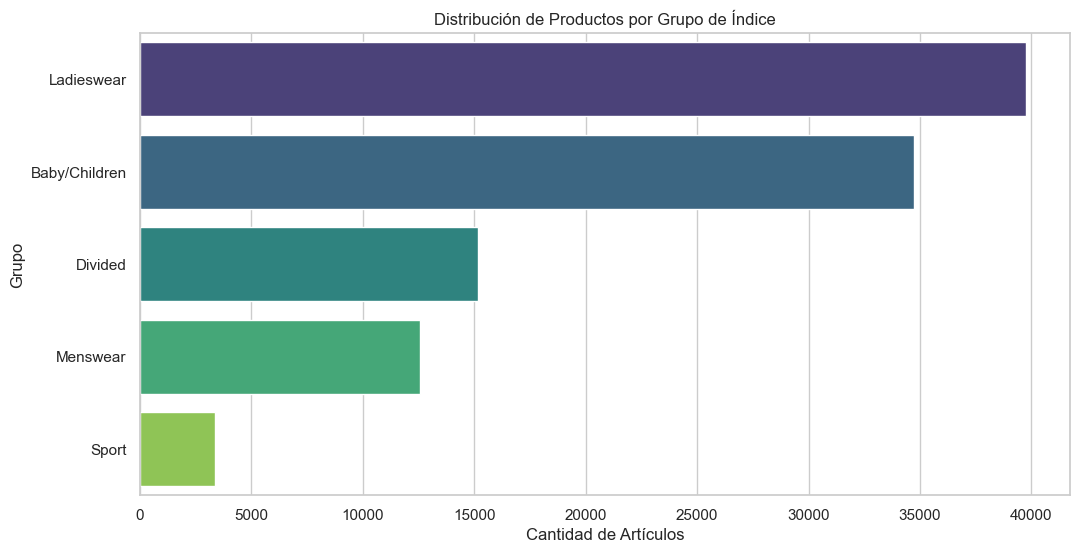

Top 10 Tipos de Productos:
product_type_name
Trousers    11169
Dress       10362
Sweater      9302
T-shirt      7904
Top          4155
Blouse       3979
Jacket       3940
Shorts       3939
Shirt        3405
Vest top     2991
Name: count, dtype: int64


In [8]:
# Vamos a ver qué categorías dominan el catálogo
plt.figure(figsize=(12, 6))
sns.countplot(data=articles, y='index_group_name', order=articles['index_group_name'].value_counts().index, palette='viridis')
plt.title('Distribución de Productos por Grupo de Índice')
plt.xlabel('Cantidad de Artículos')
plt.ylabel('Grupo')
plt.show()

# También veamos el top 10 de tipos de productos
print("Top 10 Tipos de Productos:")
print(articles['product_type_name'].value_counts().head(10))

C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\85941682.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sold.values, y=top_sold.index, palette='magma')


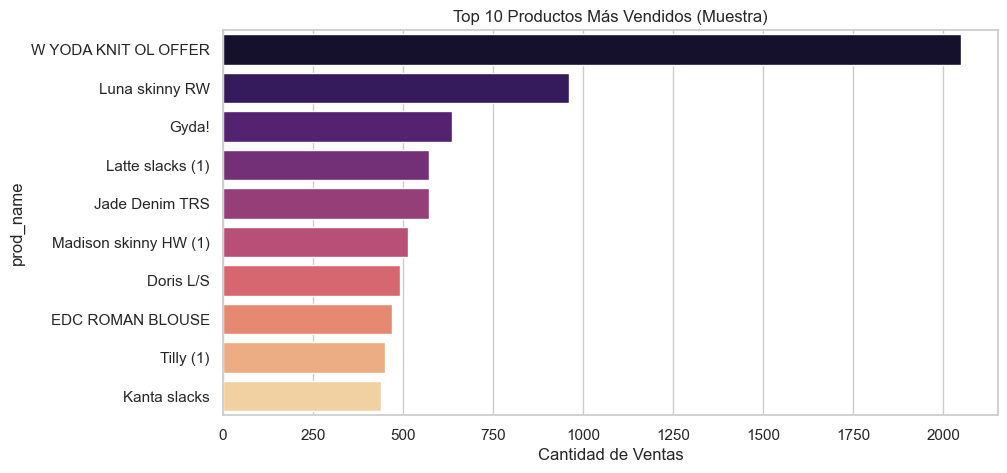

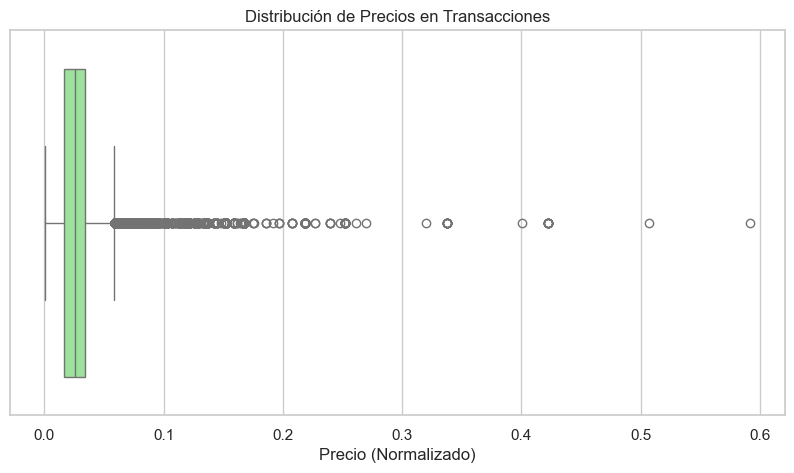

Precio promedio: 0.0296


In [9]:
# Unimos la muestra de transacciones con la información de los artículos
# Solo traemos las columnas que nos interesan para no saturar la memoria
df_merged = transactions_sample.merge(
    articles[['article_id', 'prod_name', 'product_type_name', 'index_group_name']], 
    on='article_id', 
    how='left'
)

# 1. ¿Cuáles son los productos más vendidos en nuestra muestra?
top_sold = df_merged['prod_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_sold.values, y=top_sold.index, palette='magma')
plt.title('Top 10 Productos Más Vendidos (Muestra)')
plt.xlabel('Cantidad de Ventas')
plt.show()

# 2. Análisis de precios
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_merged['price'], color='lightgreen')
plt.title('Distribución de Precios en Transacciones')
plt.xlabel('Precio (Normalizado)')
plt.show()

print(f"Precio promedio: {df_merged['price'].mean():.4f}")

Cantidad de transacciones 'caras' (> 0.1): 1801


C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\3477839262.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


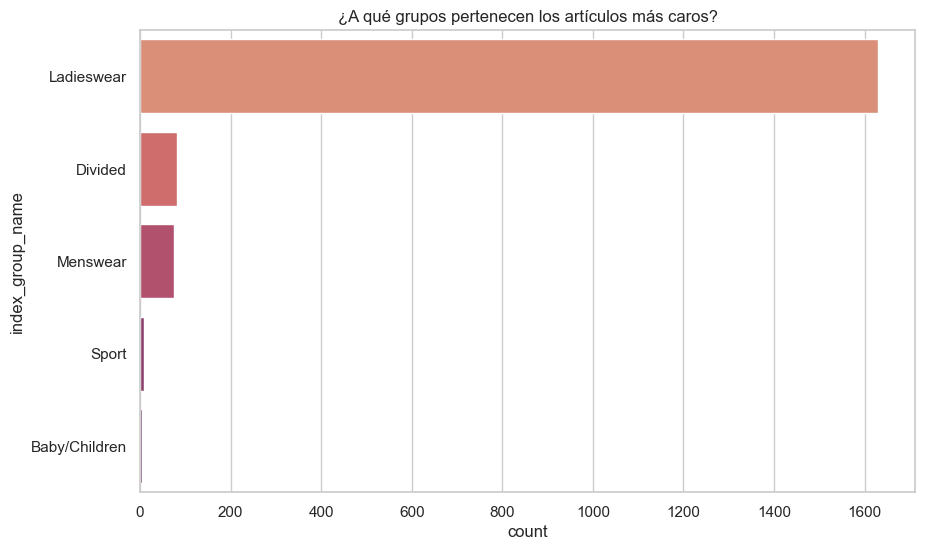

Top 5 artículos más caros vendidos:
                      prod_name     price
69300     PE LINDA LEATHER COAT  0.591525
47073         SC REINDEER biker  0.506780
55418  CLOUD unconstructed coat  0.422034
16973     Thunder Cashmere Coat  0.422034
55159           PE DANIELA COAT  0.422034


In [10]:
# Definimos un umbral para los "outliers" (por ejemplo, precio > 0.1)
umbral_outlier = 0.1
outliers_precio = df_merged[df_merged['price'] > umbral_outlier]

print(f"Cantidad de transacciones 'caras' (> {umbral_outlier}): {len(outliers_precio)}")

# Vemos a qué grupos de productos pertenecen estos outliers
plt.figure(figsize=(10, 6))
sns.countplot(
    data=outliers_precio, 
    y='index_group_name', 
    order=outliers_precio['index_group_name'].value_counts().index,
    palette='flare'
)
plt.title('¿A qué grupos pertenecen los artículos más caros?')
plt.show()

# Ver el top 5 de productos específicos que son outliers
print("Top 5 artículos más caros vendidos:")
print(outliers_precio[['prod_name', 'price']].drop_duplicates().sort_values(by='price', ascending=False).head(5))

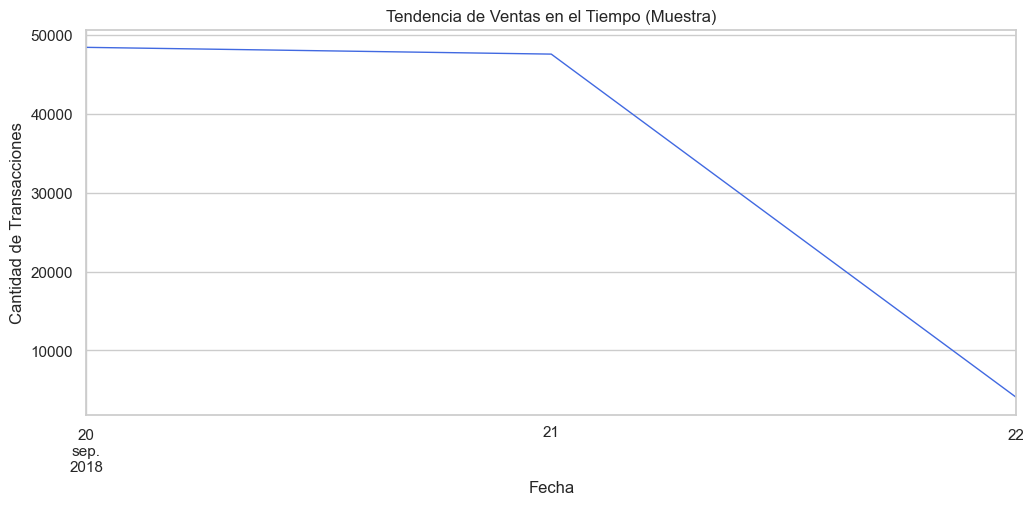

In [11]:
# Convertimos t_dat a datetime
df_merged['t_dat'] = pd.to_datetime(df_merged['t_dat'])

# Agrupamos por fecha para ver ventas diarias en la muestra
ventas_diarias = df_merged.groupby('t_dat').size()

plt.figure(figsize=(12, 5))
ventas_diarias.plot(color='royalblue', linewidth=1)
plt.title('Tendencia de Ventas en el Tiempo (Muestra)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Transacciones')
plt.show()

Promedio de artículos por cliente: 3.53
Máximo de artículos comprados por un solo cliente: 103


C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\506249256.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sales_channel_id', data=df_merged, palette='pastel')


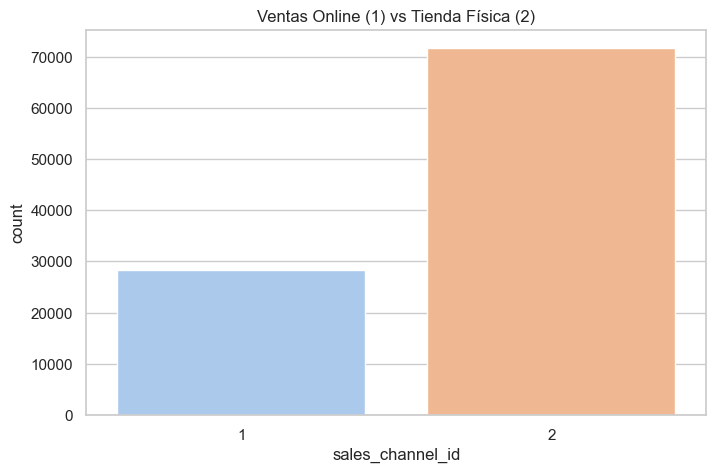

In [12]:
# 1. ¿Cuántos artículos compra cada cliente en promedio en esta muestra?
compras_por_cliente = df_merged.groupby('customer_id').size()
print(f"Promedio de artículos por cliente: {compras_por_cliente.mean():.2f}")
print(f"Máximo de artículos comprados por un solo cliente: {compras_por_cliente.max()}")

# 2. Distribución de Canales de Venta (1 = Online, 2 = Tienda Física)
plt.figure(figsize=(8, 5))
sns.countplot(x='sales_channel_id', data=df_merged, palette='pastel')
plt.title('Ventas Online (1) vs Tienda Física (2)')
plt.show()

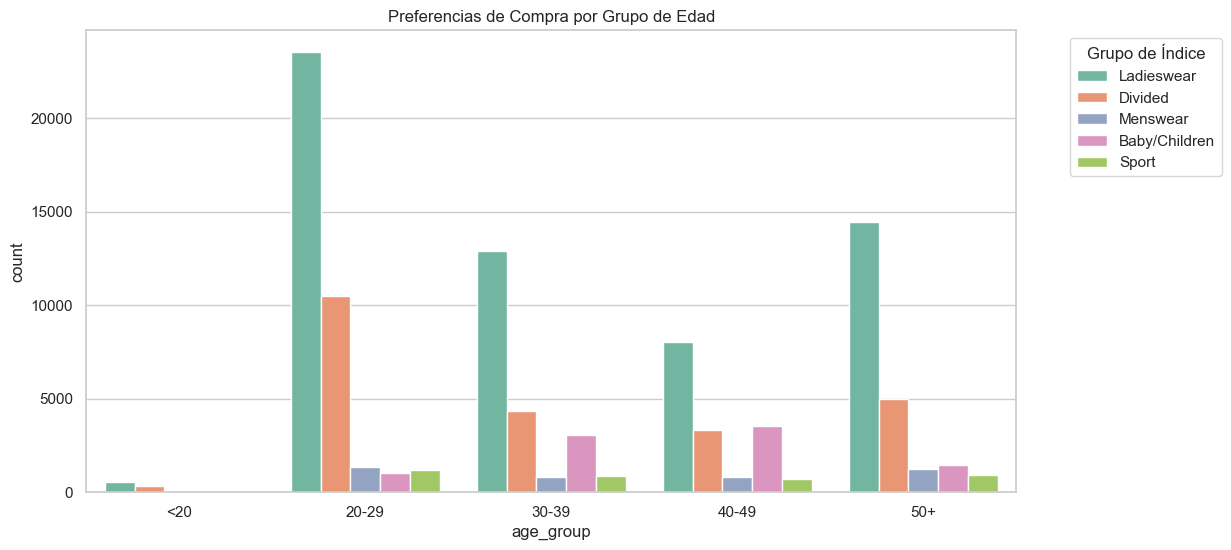

In [13]:
# Unimos con la tabla de clientes para tener la edad
df_full_info = df_merged.merge(customers[['customer_id', 'age']], on='customer_id', how='left')

# Creamos rangos de edad para facilitar la lectura
df_full_info['age_group'] = pd.cut(df_full_info['age'], bins=[0, 19, 29, 39, 49, 100], 
                                 labels=['<20', '20-29', '30-39', '40-49', '50+'])

# Graficamos qué compra cada grupo de edad
plt.figure(figsize=(12, 6))
sns.countplot(data=df_full_info, x='age_group', hue='index_group_name', palette='Set2')
plt.title('Preferencias de Compra por Grupo de Edad')
plt.legend(title='Grupo de Índice', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\487627498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full_info, x='day_of_week', order=days_order, palette='viridis')


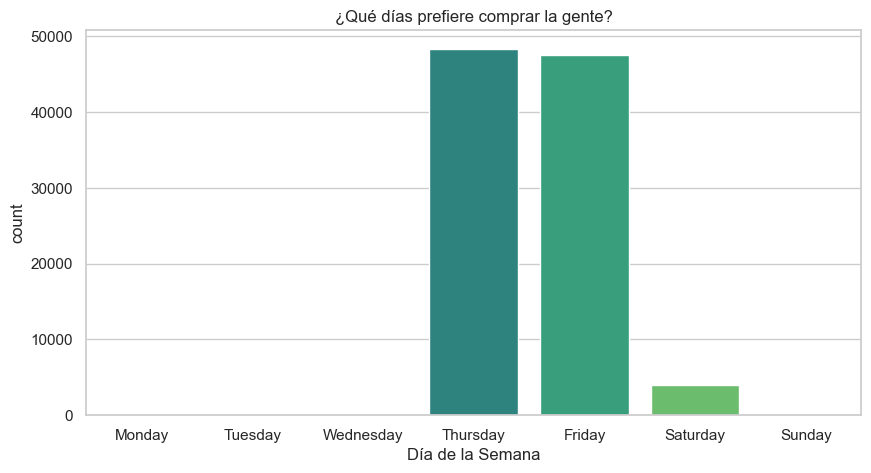

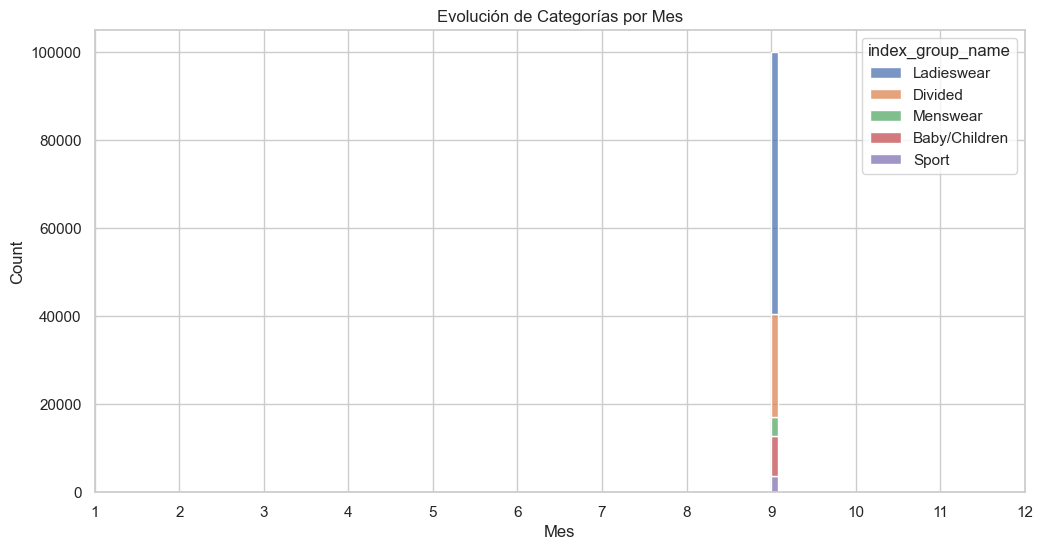

In [14]:
# Extraemos características de tiempo
df_full_info['month'] = df_full_info['t_dat'].dt.month
df_full_info['day_of_week'] = df_full_info['t_dat'].dt.day_name()

# 1. Ventas por día de la semana
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_full_info, x='day_of_week', order=days_order, palette='viridis')
plt.title('¿Qué días prefiere comprar la gente?')
plt.xlabel('Día de la Semana')
plt.show()

# 2. ¿Qué se compra más según el mes? (Top 3 categorías)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_full_info, x='month', hue='index_group_name', multiple="stack", bins=12)
plt.title('Evolución de Categorías por Mes')
plt.xlabel('Mes')
plt.xticks(range(1, 13))
plt.show()

Conteo de transacciones por mes en la nueva muestra de 5 millones de filas:
month
1      588738
9      594776
10    1397040
11    1270619
12    1148827
Name: count, dtype: int64


C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_18916\1674979958.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_transactions = df_temp.groupby('month').apply(


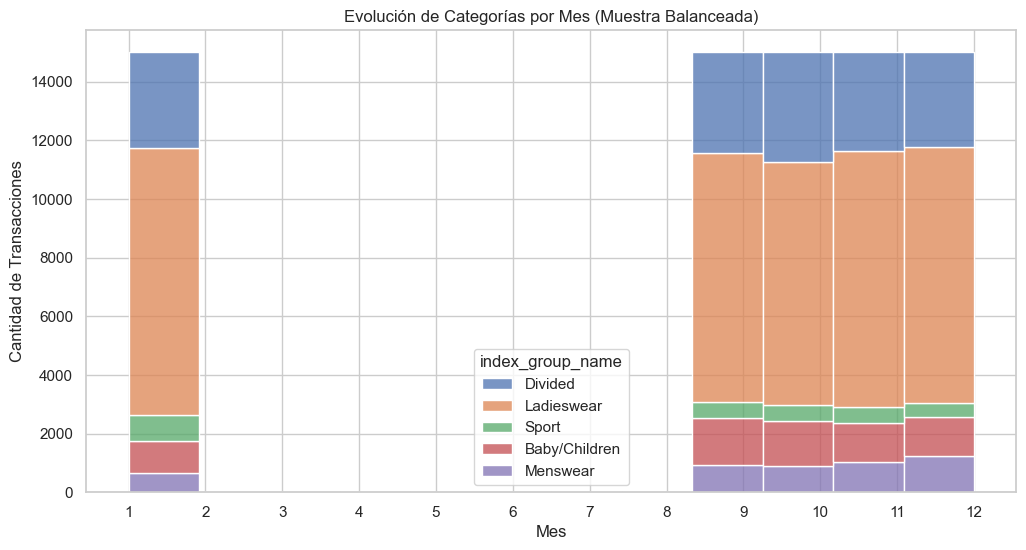

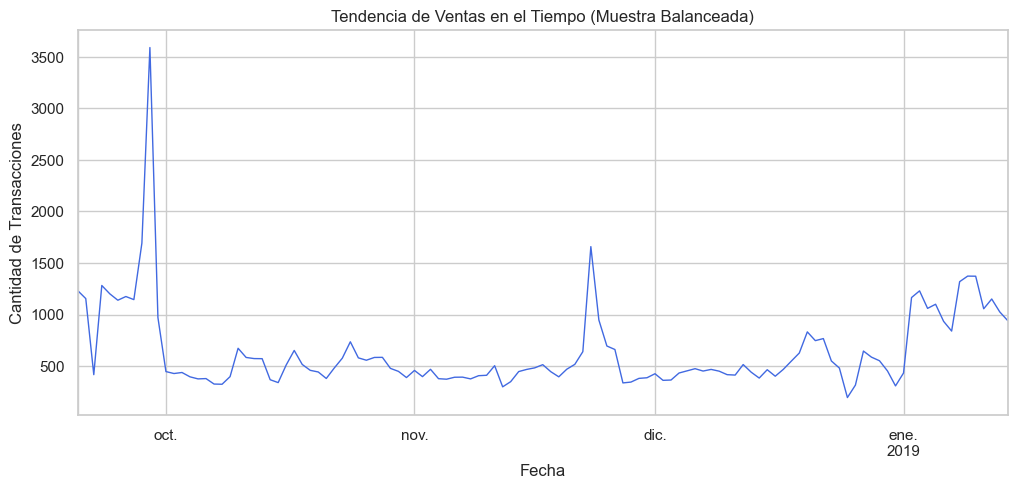

Dataframe de transacciones balanceado creado con forma: (75000, 9)


In [15]:
# Creamos una muestra más grande y distribuida para superar el sesgo cronológico.

# En lugar de las primeras 100,000, cargamos una porción más grande, por ejemplo, 5 millones.
# (Esto todavía evita cargar los 31 millones completos para ahorrar RAM).
# Si tu máquina lo maneja bien, puedes aumentar este número.
large_nrows_sample = 5000000
df_temp = pd.read_csv(
    os.path.join(data_path, "transactions_train.csv"),
    nrows=large_nrows_sample
)

# Convertimos a datetime y creamos una columna de mes
df_temp['t_dat'] = pd.to_datetime(df_temp['t_dat'])
df_temp['month'] = df_temp['t_dat'].dt.month

# Verificamos la distribución en esta muestra más grande. Debería abarcar más meses.
print("Conteo de transacciones por mes en la nueva muestra de 5 millones de filas:")
print(df_temp['month'].value_counts().sort_index())

# Ahora, muestreamos porciones iguales de cada mes presente en esta muestra más grande.
# Por ejemplo, busquemos 15,000 transacciones por mes para obtener una muestra final balanceada de 180,000 filas.
samples_per_month = 15000

# Creamos la muestra balanceada y estratificada
balanced_transactions = df_temp.groupby('month').apply(
    lambda x: x.sample(n=samples_per_month, random_state=42)
).reset_index(drop=True)

# Combinamos con los datos de artículos y clientes como antes.
# (Asegúrate de que los dataframes de articles y customers todavía estén cargados en la memoria).
df_merged_balanced = balanced_transactions.merge(
    articles[['article_id', 'prod_name', 'product_type_name', 'index_group_name']],
    on='article_id',
    how='left'
)

# Trazamos la nueva gráfica "Evolución de Categorías por Mes" con los datos balanceados
plt.figure(figsize=(12, 6))
sns.histplot(data=df_merged_balanced, x='month', hue='index_group_name', multiple="stack", bins=12)
plt.title('Evolución de Categorías por Mes (Muestra Balanceada)')
plt.xlabel('Mes')
plt.xticks(range(1, 13))
plt.ylabel('Cantidad de Transacciones')
plt.show()

# También verifiquemos la tendencia temporal para esta nueva muestra balanceada. Debería abarcar el rango completo.
ventas_diarias_balanced = df_merged_balanced.groupby('t_dat').size()
plt.figure(figsize=(12, 5))
ventas_diarias_balanced.plot(color='royalblue', linewidth=1)
plt.title('Tendencia de Ventas en el Tiempo (Muestra Balanceada)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Transacciones')
plt.show()

# Los datos finales balanceados ahora están en 'df_merged_balanced'. Podemos usarlos para futuros pasos.
print("Dataframe de transacciones balanceado creado con forma:", df_merged_balanced.shape)